In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# OOD performance

In [4]:
df_base_path = '../results'

In [17]:
# Load your three dataframes
baseline_df = pd.read_csv(f"{df_base_path}/baseline_by_celltype_correlations.csv")
cellina_df = pd.read_csv(f"{df_base_path}/cellina_by_celltype_correlations.csv")
cpa_df = pd.read_csv(f"{df_base_path}/cpa_by_celltype_correlations.csv")

# remove epithelial row from cpa
cpa_df = cpa_df[cpa_df['celltype'] != 'Epithelial']

# Add a column to identify the source dataframe
baseline_df['method'] = 'baseline'
cpa_df['method'] = 'cpa'
cellina_df['method'] = 'cellina'

# Combine them
df_all = pd.concat([baseline_df, cpa_df, cellina_df], ignore_index=True)

# Melt the dataframe so we can plot pearson and spearman separately
df_melt = df_all.melt(id_vars=['celltype', 'method'], value_vars=['pearson', 'spearman'],
                      var_name='correlation', value_name='value')

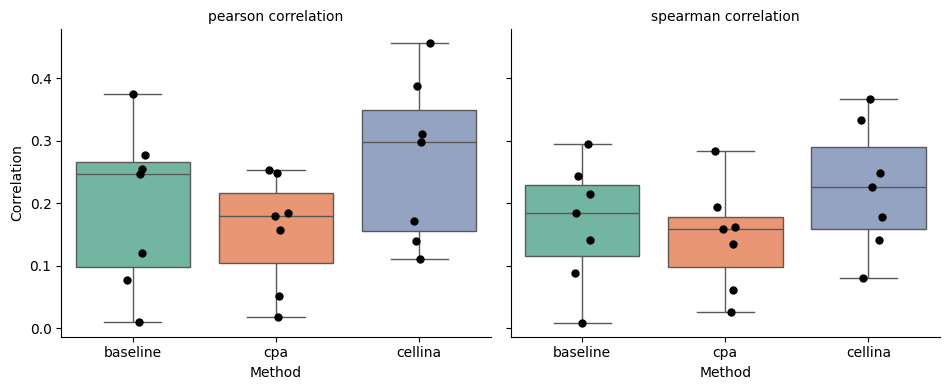

In [18]:
g = sns.catplot(
    data=df_melt, kind="box",
    x="method", y="value", hue="method",
    col="correlation",  # separate plots for pearson and spearman
    dodge=False, palette="Set2",
    height=4, aspect=1.2
)

# Add the individual points (dots) for each cell type
for ax, corr_type in zip(g.axes[0], ['pearson', 'spearman']):
    sns.stripplot(
        data=df_melt[df_melt['correlation']==corr_type],
        x='method', y='value', color='black', size=6, ax=ax, jitter=True
    )

g.set_axis_labels("Method", "Correlation")
g.set_titles("{col_name} correlation")
plt.show()

# LFC agreement between observed and reconstructed counts

In [19]:
cellina_de = pd.read_csv(f"{df_base_path}/cellina_de.csv", index_col=0).T
cpa_de = pd.read_csv(f"{df_base_path}/cpa_de.csv", index_col=0).T

In [20]:
cpa_de.index.name = "celltype"
cellina_de.index.name = "celltype"

/tmp/ipykernel_2026619/1853090153.py:14: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x="Correlation", y="Value", hue="method", data=df_melted,


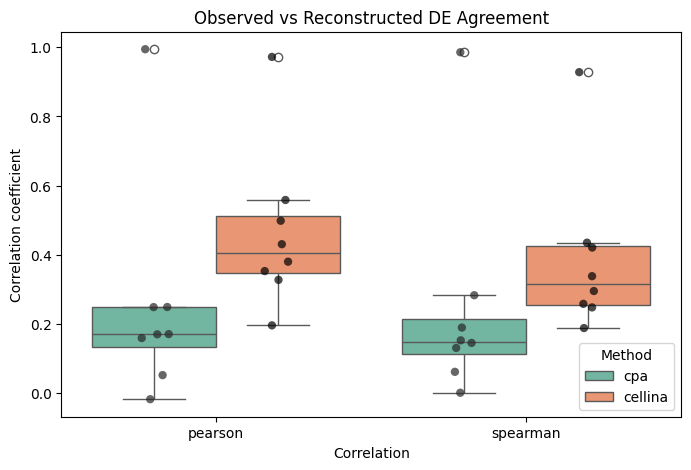

In [21]:
# Add a column to identify the source dataframe
cpa_de['method'] = 'cpa'
cellina_de['method'] = 'cellina'

# Combine both DataFrames
df_all = pd.concat([cpa_de, cellina_de])

# Melt for seaborn: long-form
df_melted = df_all.reset_index().melt(id_vars=["celltype", "method"], var_name="Correlation", value_name="Value")

# Plot
plt.figure(figsize=(8,5))
sns.boxplot(x="Correlation", y="Value", hue="method", data=df_melted, palette="Set2")
sns.stripplot(x="Correlation", y="Value", hue="method", data=df_melted,
              dodge=True, color="black", size=6, jitter=True, alpha=0.7)

# Remove duplicate legend entries from stripplot
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Method")

plt.title("Observed vs Reconstructed DE Agreement")
plt.ylabel("Correlation coefficient")
plt.show()

# E-distances between observed and reconstructed cells

In [22]:
cellina_edist = pd.read_csv(f"{df_base_path}/cellina_edist.csv", index_col=0)
cpa_edist = pd.read_csv(f"{df_base_path}/cpa_edist.csv", index_col=0)

In [23]:
cpa_edist.index.name = "celltype"
cellina_edist.index.name = "celltype"

/tmp/ipykernel_2026619/1993656564.py:14: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x="Edistance", y="Value", hue="method", data=df_melted,


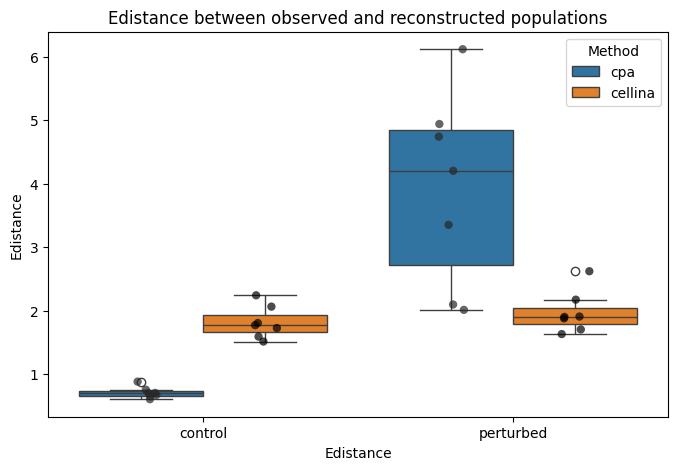

In [24]:
# Add a column to identify the source dataframe
cpa_edist['method'] = 'cpa'
cellina_edist['method'] = 'cellina'

# Combine both DataFrames
df_all = pd.concat([cpa_edist, cellina_edist])

# Melt for seaborn: long-form
df_melted = df_all.reset_index().melt(id_vars=["celltype", "method"], var_name="Edistance", value_name="Value")

# Plot
plt.figure(figsize=(8,5))
sns.boxplot(x="Edistance", y="Value", hue="method", data=df_melted, palette="tab10")
sns.stripplot(x="Edistance", y="Value", hue="method", data=df_melted,
              dodge=True, color="black", size=6, jitter=True, alpha=0.7)

# Remove duplicate legend entries from stripplot
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Method")

plt.title("Edistance between observed and reconstructed populations")
plt.ylabel("Edistance")
plt.show()

# LOO plots

In [211]:
import os
import glob
import json

corr_dir = "/data2/a330d/datasets/crc/correlations"
pattern = os.path.join(corr_dir, "crc_*.json")
files = sorted(glob.glob(pattern))

rows = []
for fp in files:
    name = os.path.basename(fp)
    if not name.startswith("crc_") or not name.endswith(".json"):
        continue
    core = name[len("crc_"):-len(".json")]
    parts = core.split("_")
    if len(parts) < 3:
        # unexpected filename, skip
        continue
    sid = parts[0]
    model_name = parts[1]
    
    holdout_celltype = "_".join(parts[2:])
    try:
        with open(fp, "r") as f:
            data = json.load(f)
    except Exception:
        # skip unreadable/invalid json
        continue

    try:
        rows.append({
            "sid": sid,
            "model_name": model_name,
            "holdout_celltype": holdout_celltype,
            "spearman": data.get("spearman"),
            "pearson": data.get("pearson"),
            "precision": data.get("precision@50"),
            "edistance_cells": data.get("edistance_cells"),
            "edistance_latents": data.get("edistance_latents"),
            "edistance_local": data.get("edistance_local"),
            "mixing_index": data.get("mixing_index")
        })
    except Exception as e:
        print(f"Error processing file {fp}: {e}")
        continue

columns = ["sid", "model_name", "holdout_celltype", "spearman", "pearson", "precision", "edistance_cells", "edistance_latents", "edistance_local", "mixing_index"]
crc_corr_df = pd.DataFrame(rows, columns=columns)

In [212]:
keep_rows = ['cf']
# Match substring from above and keep those rows
crc_corr_df = crc_corr_df[crc_corr_df['model_name'].str.contains('|'.join(keep_rows))]
# Remove rows which contain 'recon' substring
discard_models = ['recon']
crc_corr_df = crc_corr_df[~crc_corr_df['model_name'].str.contains('|'.join(discard_models))]
# Remove B cell results - Reason: Missing in two slides
discard_celltypes = ['B_cell']
crc_corr_df = crc_corr_df[~crc_corr_df['holdout_celltype'].isin(discard_celltypes)]
# Remove rows of sid 110, 222 - Reason: 110 has very low correlations for all models, 222 does not have CRC
discard_slides = ['110', '222']
crc_corr_df = crc_corr_df[~crc_corr_df['sid'].isin(discard_slides)]

In [213]:
# Load mintflow results
df = crc_corr_df.copy() # start with existing dataframe
mintflow_base_path = "/data/a330d/projects/cellina-reproducibility/results/mintflow_crc"
mintflow_model_name = "mintflow-normalized"
load_sids_mintflow = ['231', '210', '242', '232', '221']
for i in load_sids_mintflow:
    mintflow_df = pd.read_csv(f"{mintflow_base_path}/{mintflow_model_name}_{i}_by_celltype_correlations.csv")
    df = pd.concat([df, mintflow_df], ignore_index=True)

In [214]:
model_rename = {
    #"cellina": "cellina",
    #"cellina-cf-recon": "cellina-recon",
    "cellina-cf": "cellina",
    "cpa-cf": "cpa",
    "baseline-cf": "baseline",
    "scgen-cf": "scgen",
    "cellina-ablated-cf": "cellina-ablated",
    "cellina-mmd-cf": "cellina-mmd",
    "cellina-graph-cf": "cellina-graph",
    mintflow_model_name: "mintflow"
}

# Rename
df.loc[:, "model_name"] = df["model_name"].map(model_rename)

In [204]:
metrics = ["pearson", "spearman", "precision"]
#metrics = ["pearson", "spearman", "precision", "mixing_index"]
#metrics = ["edistance_cells", "edistance_local"]
grouping = "holdout_celltype"

# Define order
model_order = [
    "baseline",
    "mintflow",
    "cpa",
    "scgen",
    "cellina-ablated",
    "cellina-mmd",
    "cellina-graph",
    "cellina",
]

default_palette = 'colorblind'
palette = default_palette

In [205]:
# Base palette (colorblind-friendly)
base_colors = sns.color_palette(default_palette, n_colors=len(model_order))

# Convert to dict mapped by model name
palette_dict = dict(zip(model_order, base_colors))

# Create a red gradient for the 3 cellina models
cellina_reds = sns.color_palette("Reds", 5)[1:] 

# skip the lightest so it's still visible
palette_dict["cellina-ablated"] = cellina_reds[0]
palette_dict["cellina-mmd"]     = cellina_reds[1]
palette_dict["cellina-graph"]   = cellina_reds[2]
palette_dict["cellina"]         = cellina_reds[3]

# non-spatial green
#palette_dict["mintflow"]   = sns.color_palette("Greens", 4)[1]
palette_dict["scgen"]   = sns.color_palette("Greens", 4)[2]
palette_dict["cpa"] = sns.color_palette("Greens", 4)[3]

palette = palette_dict

In [206]:
rank_results = []

for metric in metrics:
    tmp = df.copy()

    # Rank within each cell type (lower = better)
    tmp["rank"] = tmp.groupby(grouping)[metric].rank(ascending=False)

    # Aggregate mean + SE
    agg = (
        tmp.groupby("model_name")["rank"]
        .agg(["mean", "sem"])
        .reset_index()
    )

    agg["metric"] = metric
    rank_results.append(agg)

rank_df = pd.concat(rank_results, ignore_index=True)

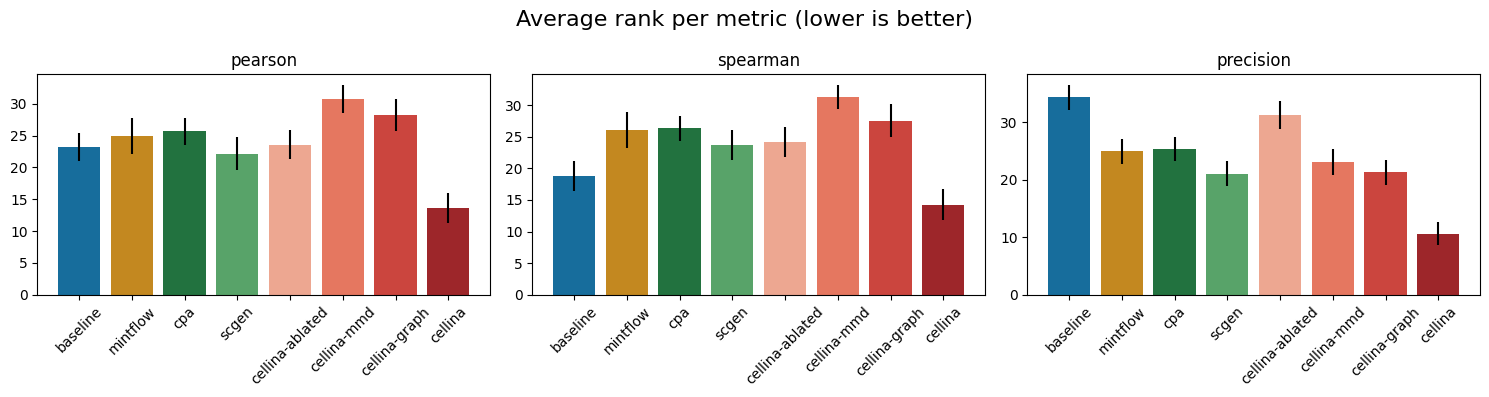

In [207]:
fig, axes = plt.subplots(1, len(metrics), figsize=(5*len(metrics), 4))
fig.suptitle('Average rank per metric (lower is better)', fontsize=16)

if len(metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics):
    sub = rank_df[rank_df.metric == metric]

    sns.barplot(
        data=sub,
        x="model_name",
        y="mean",
        hue="model_name",
        order=model_order,
        palette=palette,
        errorbar=None,  # we add manually
        ax=ax
    )

    # Add SE bars
    for i, model in enumerate(model_order):
        row = sub[sub.model_name == model].iloc[0]
        ax.errorbar(
            x=i,
            y=row["mean"],
            yerr=row["sem"],
            fmt="none",
            capsize=0,
            color="black",
        )

    ax.set_title(f"{metric}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [208]:
def plot_model_comparison(
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    title="Performance (observed vs predicted) for DEG 50 (higher is better)",
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Compute global y-limits
    ymin = df[metrics].min().min() * 0.95
    ymax = df[metrics].max().max() * 1.05

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))
    fig.suptitle(title, fontsize=16)

    # Ensure axes iterable if only one metric
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):

        if not average_only:
            # -------------------------------
            # Per-celltype plot
            # -------------------------------
            celltypes = df[grouping].unique().tolist()
            all_x_labels = list(celltypes) + ["Average"]

            sns.barplot(
                data=df,
                x=grouping,
                y=metric,
                hue="model_name",
                estimator="mean",
                errorbar="se",
                hue_order=model_order,
                ax=ax,
                palette=palette,
                order=celltypes,
            )
            ax.legend_.remove()

            # -------------------------------
            # Add averages manually (WITH SE)
            # -------------------------------
            df_avg = df.groupby("model_name")[metric].mean()
            df_se = df.groupby("model_name")[metric].sem()

            n_models = len(model_order)
            bar_width = 0.8 / n_models

            for i, model in enumerate(model_order):
                avg_val = df_avg.loc[model]
                se_val = df_se.loc[model]

                x_pos = len(celltypes) - 0.4 + i * bar_width + bar_width / 2

                ax.bar(
                    x=x_pos,
                    height=avg_val,
                    width=bar_width,
                    color=palette[model],
                    alpha=0.9,
                    yerr=se_val,
                    capsize=0,
                )

            ax.set_xticks(range(len(all_x_labels)))
            ax.set_xticklabels(all_x_labels, rotation=45)

        else:
            # -------------------------------
            # AVERAGE-ONLY plot (clean)
            # -------------------------------
            df_avg = (
                df.groupby(["model_name"])[metric]
                .agg(["mean", "sem"])
                .reset_index()
            )

            sns.barplot(
                data=df_avg,
                x="model_name",
                y="mean",
                hue="model_name",
                order=model_order,
                palette=palette,
                errorbar=None,  # we add manually
                ax=ax,
            )

            # Add SE manually
            for i, model in enumerate(model_order):
                row = df_avg[df_avg.model_name == model].iloc[0]
                ax.errorbar(
                    x=i,
                    y=row["mean"],
                    yerr=row["sem"],
                    fmt="none",
                    capsize=0,
                    color="black",
                )

            #ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
            ax.tick_params(axis="x", rotation=45)

        # -------------------------------
        # Shared styling
        # -------------------------------
        ax.set_ylim(ymin, ymax)
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.set_ylabel("")

    # -------------------------------
    # Global legend (only once)
    # -------------------------------
    if not average_only:
        handles, labels = axes[0].get_legend_handles_labels()
    else:
        handles = [
            plt.Rectangle((0, 0), 1, 1, color=palette[m])
            for m in model_order
        ]
        labels = model_order

    fig.legend(
        handles,
        labels,
        ncol=len(labels),
        fontsize=10,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)
    plt.show()

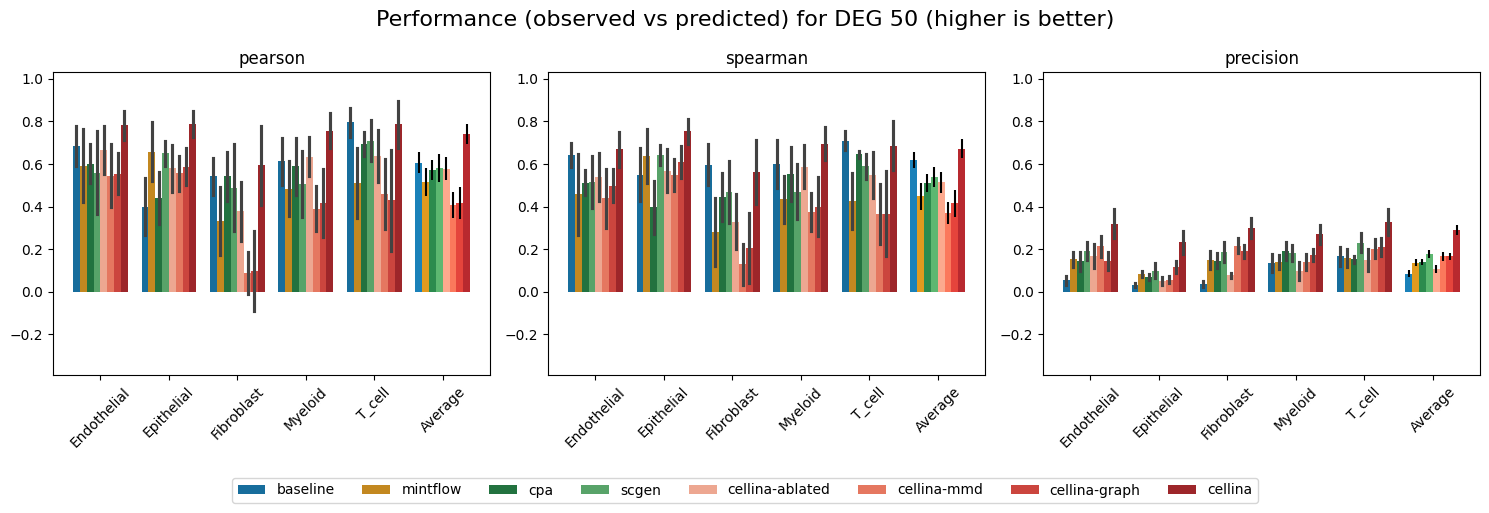

In [209]:
plot_model_comparison(
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
)

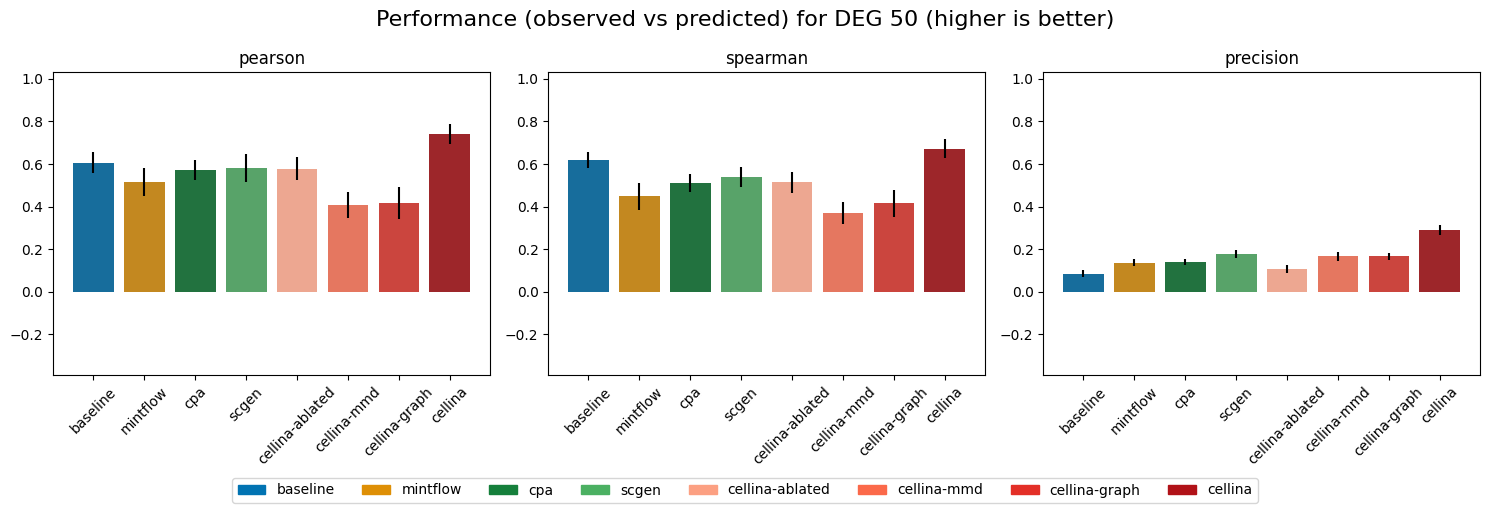

In [210]:
plot_model_comparison(
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=True,
)

In [216]:
df.to_csv("../results/loo_summary.csv", index=False)